<a href="https://colab.research.google.com/github/ahamedcader8055-gtr/NorthStar-Analytics/blob/main/NorthStar_Part_2_R_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
install.packages("DBI")
install.packages("RSQLite")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("tidyr")
install.packages("lubridate")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)
library(tidyr)
library(lubridate)

# Load all 10 CSV files
customers   <- read.csv("/content/customers.csv")
complaints  <- read.csv("/content/complaints.csv")
app_events  <- read.csv("/content/app_events.csv")
deliveries  <- read.csv("/content/deliveries.csv")
drivers     <- read.csv("/content/drivers.csv")
hubs        <- read.csv("/content/hubs.csv")
incidents   <- read.csv("/content/incidents.csv")
orders      <- read.csv("/content/orders.csv")
vehicles    <- read.csv("/content/vehicles.csv")
data_dict   <- read.csv("/content/data_dictionary.csv")

# Create SQL database
con <- dbConnect(SQLite(), ":memory:")
dbWriteTable(con, "customers",  customers)
dbWriteTable(con, "complaints", complaints)
dbWriteTable(con, "app_events", app_events)
dbWriteTable(con, "deliveries", deliveries)
dbWriteTable(con, "drivers",    drivers)
dbWriteTable(con, "hubs",       hubs)
dbWriteTable(con, "incidents",  incidents)
dbWriteTable(con, "orders",     orders)
dbWriteTable(con, "vehicles",   vehicles)
dbWriteTable(con, "data_dict",  data_dict)

cat("All 10 files loaded and database ready!\n")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




All 10 files loaded and database ready!


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


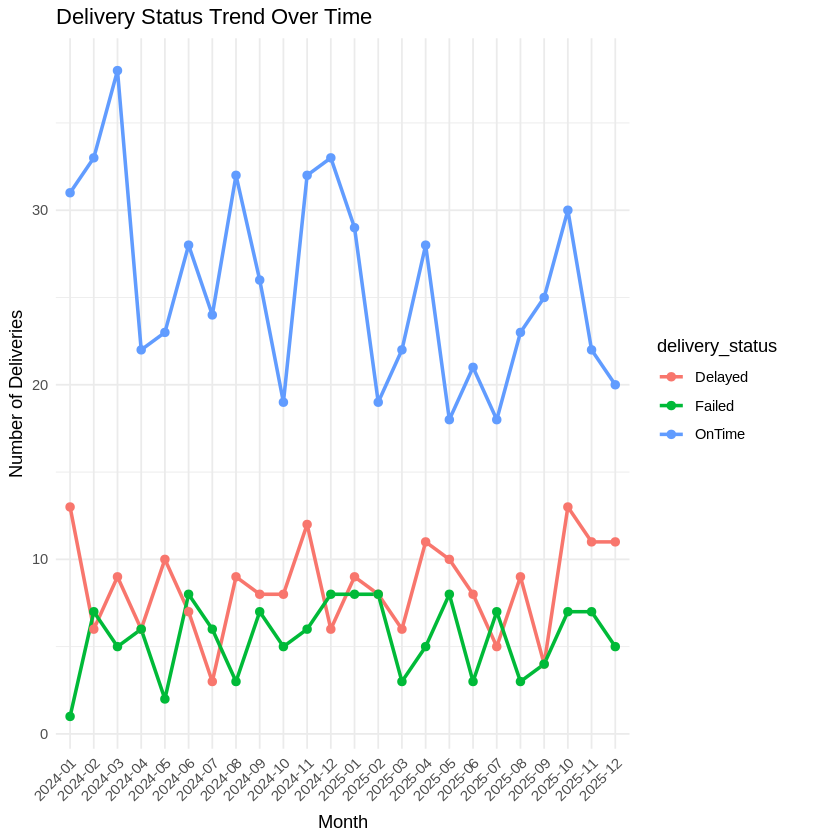

In [4]:
# Convert date columns to proper date format
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time,
                                        format="%Y-%m-%d %H:%M:%S")
orders$order_created_at  <- as.POSIXct(orders$order_created_at,
                                        format="%Y-%m-%d %H:%M:%S")

# Extract month and year
deliveries$month_year <- format(deliveries$dispatch_time, "%Y-%m")
orders$month_year     <- format(orders$order_created_at,  "%Y-%m")

# Delivery status trend over time
trend1 <- deliveries %>%
  group_by(month_year, delivery_status) %>%
  summarise(total=n(), .groups="drop") %>%
  filter(!is.na(month_year))

# Plot delivery trend
ggplot(trend1, aes(x=month_year, y=total,
                   color=delivery_status, group=delivery_status)) +
  geom_line(size=1) +
  geom_point(size=2) +
  labs(title="Delivery Status Trend Over Time",
       x="Month", y="Number of Deliveries") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1))

                            is_failed manual_route_override_count
is_failed                        1.00                        0.02
manual_route_override_count      0.02                        1.00
proof_of_completion_missing      0.17                        0.04
fuel_or_charge_cost              0.03                        0.11
route_distance_km               -0.03                        0.20
training_score                   0.07                        0.01
driver_rating                   -0.08                       -0.02
years_experience                 0.11                       -0.01
battery_health_pct              -0.04                        0.00
odometer_km                      0.00                        0.01
                            proof_of_completion_missing fuel_or_charge_cost
is_failed                                          0.17                0.03
manual_route_override_count                        0.04                0.11
proof_of_completion_missing                   

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



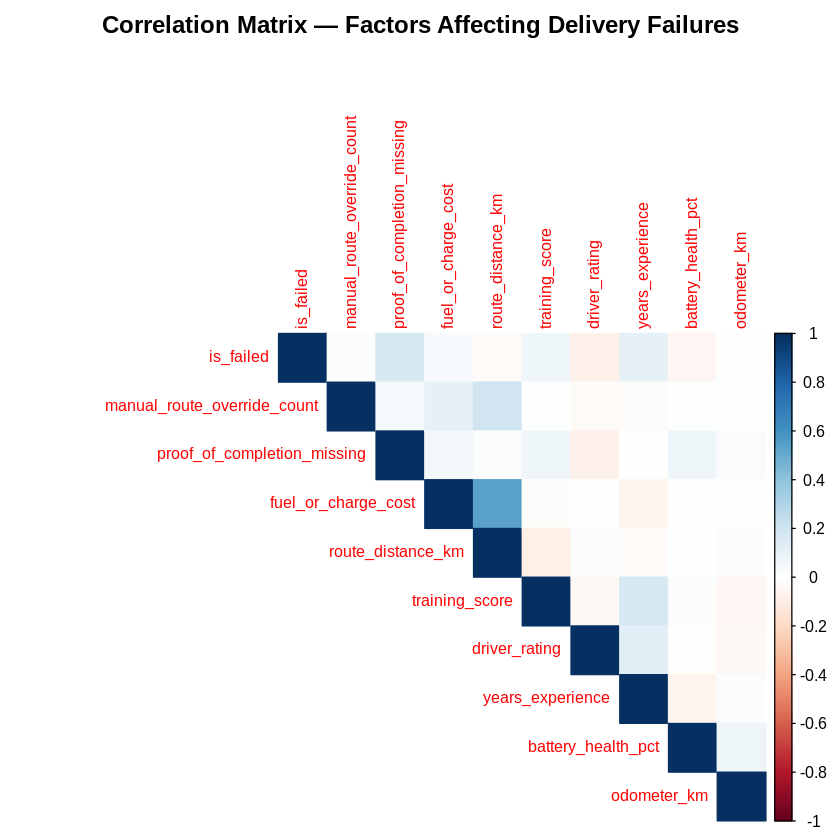

In [5]:
# Create numeric dataset for correlation
corr_data <- deliveries %>%
  left_join(drivers,  by="driver_id") %>%
  left_join(vehicles, by="vehicle_id") %>%
  mutate(is_failed = ifelse(delivery_status=="Failed", 1, 0)) %>%
  select(is_failed,
         manual_route_override_count,
         proof_of_completion_missing,
         fuel_or_charge_cost,
         route_distance_km,
         training_score,
         driver_rating,
         years_experience,
         battery_health_pct,
         odometer_km) %>%
  na.omit()

# Calculate correlation matrix
corr_matrix <- cor(corr_data)
print(round(corr_matrix, 2))

# Visualise correlation matrix
install.packages("corrplot")
library(corrplot)
corrplot(corr_matrix,
         method="color",
         type="upper",
         tl.cex=0.8,
         title="Correlation Matrix — Factors Affecting Delivery Failures",
         mar=c(0,0,2,0))

# A tibble: 8 × 13
  hub_name       zone      hub_type capacity_score total_deliveries failure_rate
  <chr>          <chr>     <chr>             <int>            <int>        <dbl>
1 East Dock      East      Warehou…             74              119         9.24
2 North Exchange North     Dispatch             82              136        12.5 
3 South Link     South     Dispatch             78              106         9.43
4 Riverside Hub  Riverside Warehou…             66              115        12.2 
5 West Gate      West      Dispatch             69              127        12.6 
6 Midtown Relay  Central   Charging             63              128        20.3 
7 Airport Hub    Airport   Dispatch             71              104        14.4 
8 Central Core   Central   Control              88              115        20   
# ℹ 7 more variables: delay_rate <dbl>, ontime_rate <dbl>, avg_rating <dbl>,
#   avg_cost <dbl>, total_overrides <int>, missing_proof_pct <dbl>,
#   efficiency_score <dbl>

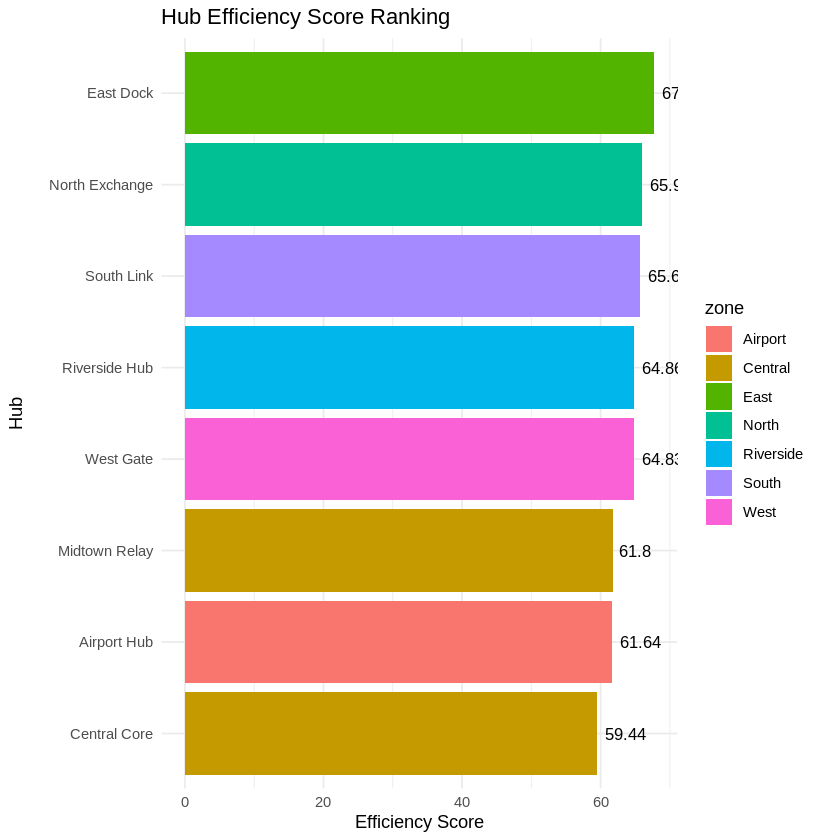

In [6]:
# Hub efficiency scoring — rank all hubs with a combined score
hub_scores <- deliveries %>%
  left_join(hubs, by="hub_id") %>%
  group_by(hub_name, zone, hub_type, capacity_score) %>%
  summarise(
    total_deliveries    = n(),
    failure_rate        = round(sum(delivery_status=="Failed") / n() * 100, 2),
    delay_rate          = round(sum(delivery_status=="Delayed") / n() * 100, 2),
    ontime_rate         = round(sum(delivery_status=="OnTime") / n() * 100, 2),
    avg_rating          = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2),
    avg_cost            = round(mean(fuel_or_charge_cost, na.rm=TRUE), 2),
    total_overrides     = sum(manual_route_override_count),
    missing_proof_pct   = round(sum(proof_of_completion_missing) / n() * 100, 2),
    .groups="drop"
  ) %>%
  mutate(
    efficiency_score = round(
      (ontime_rate * 0.4) +
      (avg_rating * 10 * 0.3) +
      ((100 - failure_rate) * 0.2) +
      ((100 - missing_proof_pct) * 0.1), 2)
  ) %>%
  arrange(desc(efficiency_score))

print(hub_scores)

# Visualise hub efficiency scores
ggplot(hub_scores, aes(x=reorder(hub_name, efficiency_score),
                       y=efficiency_score, fill=zone)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=efficiency_score), hjust=-0.2, size=3.5) +
  coord_flip() +
  labs(title="Hub Efficiency Score Ranking",
       x="Hub", y="Efficiency Score") +
  theme_minimal()

# A tibble: 20 × 10
   driver_id employment_type base_zone total_deliveries failed on_time
   <chr>     <chr>           <chr>                <int>  <int>   <int>
 1 D007      FullTime        North                    2      0       2
 2 D009      FullTime        Airport                  5      0       5
 3 D012      FullTime        SOUTH                    2      0       2
 4 D014      FullTime        NORTH                    4      0       4
 5 D015      FullTime        East                     6      0       6
 6 D020      FullTime        East                     4      0       4
 7 D025      FullTime        North                    3      0       3
 8 D029      Contract        EAST                     1      0       1
 9 D032      PartTime        East                     4      0       4
10 D035      FullTime        Ctr                      2      0       2
11 D044      FullTime        AIRPORT                  3      0       3
12 D047      FullTime        South                    5  

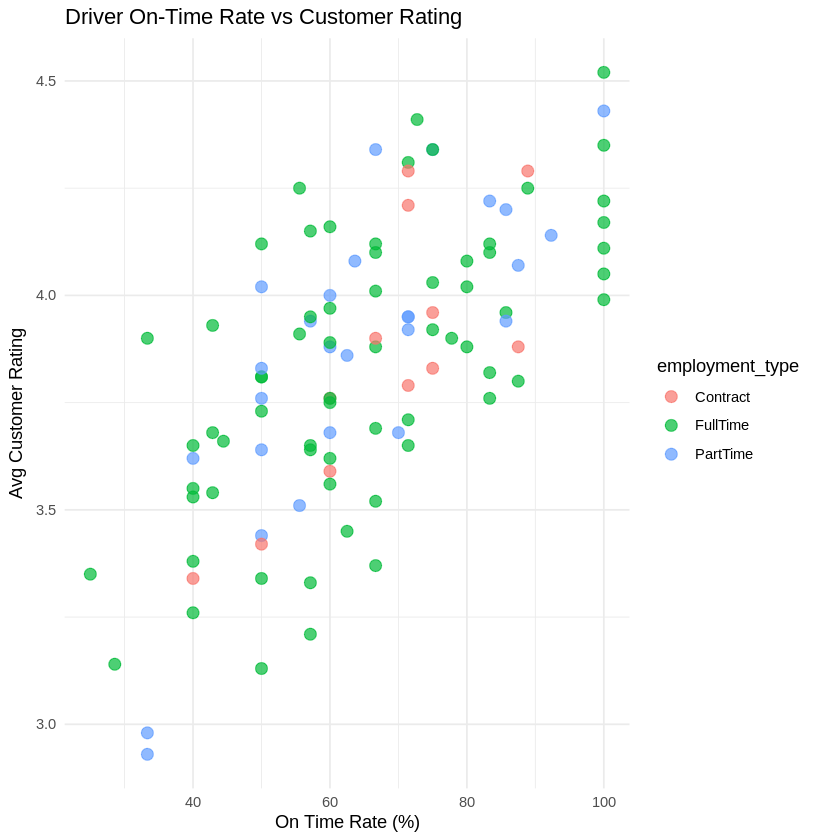

In [14]:
#Driver Performance Ranking
driver_performance <- deliveries %>%
  left_join(drivers, by="driver_id") %>%
  group_by(driver_id, employment_type, base_zone) %>%
  summarise(
    total_deliveries = n(),
    failed           = sum(delivery_status=="Failed"),
    on_time          = sum(delivery_status=="OnTime"),
    failure_rate     = round(sum(delivery_status=="Failed")/n()*100, 2),
    ontime_rate      = round(sum(delivery_status=="OnTime")/n()*100, 2),
    avg_rating       = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2),
    total_overrides  = sum(manual_route_override_count),
    .groups="drop"
  ) %>%
  arrange(desc(ontime_rate))

print(head(driver_performance, 20))

ggplot(driver_performance %>% filter(total_deliveries >= 5),
       aes(x=ontime_rate, y=avg_rating, color=employment_type)) +
  geom_point(size=3, alpha=0.7) +
  labs(title="Driver On-Time Rate vs Customer Rating",
       x="On Time Rate (%)", y="Avg Customer Rating") +
  theme_minimal()

# A tibble: 12 × 7
   vehicle_type maintenance_status total_deliveries failed failure_rate
   <chr>        <chr>                         <int>  <int>        <dbl>
 1 CargoVan     InRepair                         68     22        32.4 
 2 Diesel       InRepair                         55     17        30.9 
 3 Hybrid       InRepair                         71     21        29.6 
 4 EV           InRepair                         60     17        28.3 
 5 CargoVan     Scheduled                        38      5        13.2 
 6 Hybrid       Active                          131     15        11.4 
 7 Diesel       Scheduled                         9      1        11.1 
 8 Diesel       Active                           80      8        10   
 9 CargoVan     Active                          117     11         9.4 
10 EV           Active                          214     11         5.14
11 Hybrid       Scheduled                        42      2         4.76
12 EV           Scheduled                    

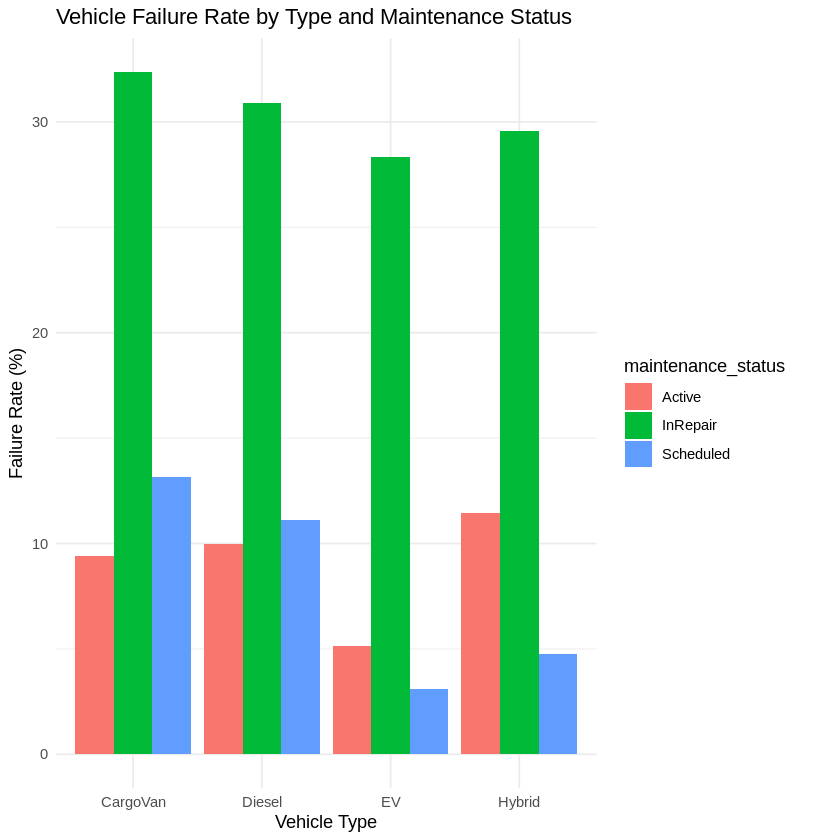

In [15]:
#Vehicle Health Analysis
vehicle_health <- deliveries %>%
  left_join(vehicles, by="vehicle_id") %>%
  group_by(vehicle_type, maintenance_status) %>%
  summarise(
    total_deliveries = n(),
    failed           = sum(delivery_status=="Failed"),
    failure_rate     = round(sum(delivery_status=="Failed")/n()*100, 2),
    avg_rating       = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2),
    avg_battery      = round(mean(battery_health_pct, na.rm=TRUE), 2),
    .groups="drop"
  ) %>%
  arrange(desc(failure_rate))

print(vehicle_health)

ggplot(vehicle_health, aes(x=vehicle_type, y=failure_rate,
                            fill=maintenance_status)) +
  geom_bar(stat="identity", position="dodge") +
  labs(title="Vehicle Failure Rate by Type and Maintenance Status",
       x="Vehicle Type", y="Failure Rate (%)") +
  theme_minimal()

# A tibble: 9 × 7
  customer_type account_status total_customers avg_loyalty avg_engagement
  <chr>         <chr>                    <int>       <dbl>          <dbl>
1 Enterprise    Suspended                    2        72             63.7
2 Consumer      Suspended                   13        64.6           56.1
3 Consumer      Active                     406        60.4           58.5
4 SME           Suspended                    5        60.1           61.7
5 Enterprise    Dormant                      6        59.6           51.4
6 Enterprise    Active                      42        58.7           55.3
7 Consumer      Dormant                     57        58.4           59.8
8 SME           Active                     104        57.8           58.0
9 SME           Dormant                     15        54             53.9
# ℹ 2 more variables: avg_failure_rate <dbl>, avg_order_value <dbl>


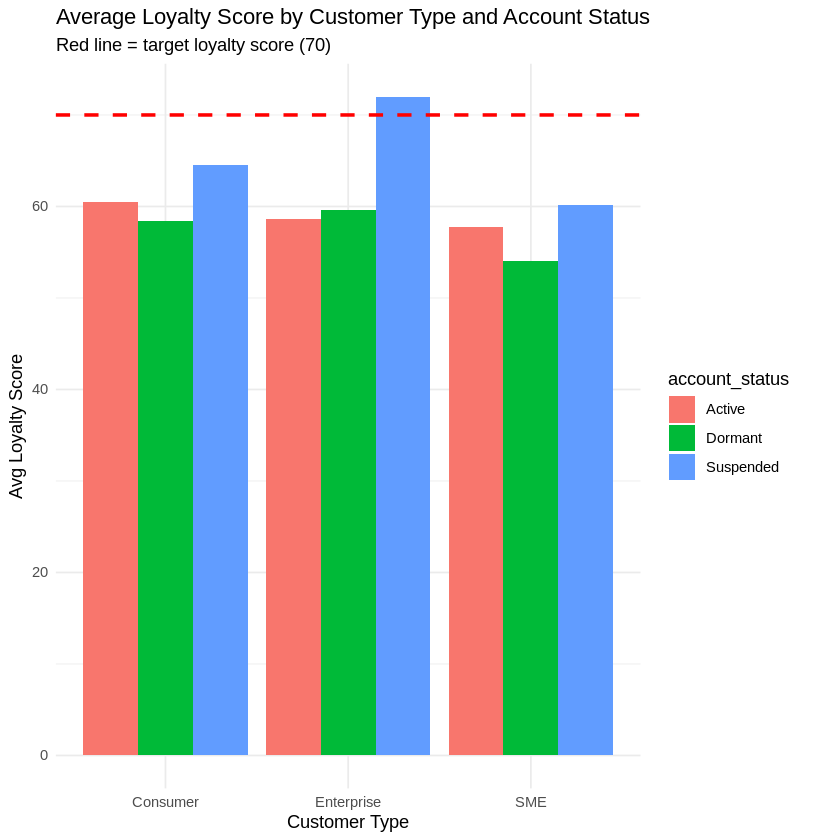

In [16]:
#Customer Segmentation Analysis
customer_segmentation <- customers %>%
  left_join(
    orders %>%
      left_join(deliveries, by="order_id") %>%
      group_by(customer_id) %>%
      summarise(
        total_orders     = n(),
        failed_orders    = sum(delivery_status=="Failed", na.rm=TRUE),
        failure_rate     = round(sum(delivery_status=="Failed", na.rm=TRUE)/n()*100, 2),
        avg_order_value  = round(mean(order_value, na.rm=TRUE), 2),
        .groups="drop"
      ),
    by="customer_id"
  ) %>%
  group_by(customer_type, account_status) %>%
  summarise(
    total_customers  = n(),
    avg_loyalty      = round(mean(loyalty_score, na.rm=TRUE), 2),
    avg_engagement   = round(mean(app_engagement_score, na.rm=TRUE), 2),
    avg_failure_rate = round(mean(failure_rate, na.rm=TRUE), 2),
    avg_order_value  = round(mean(avg_order_value, na.rm=TRUE), 2),
    .groups="drop"
  ) %>%
  arrange(desc(avg_loyalty))

print(customer_segmentation)

ggplot(customer_segmentation,
       aes(x=customer_type, y=avg_loyalty, fill=account_status)) +
  geom_bar(stat="identity", position="dodge") +
  geom_hline(yintercept=70, color="red", linetype="dashed",
             size=1, show.legend=TRUE) +
  labs(title="Average Loyalty Score by Customer Type and Account Status",
       subtitle="Red line = target loyalty score (70)",
       x="Customer Type", y="Avg Loyalty Score") +
  theme_minimal()

# A tibble: 21 × 5
   complaint_type  severity total avg_resolution avg_compensation
   <chr>           <chr>    <int>          <dbl>            <dbl>
 1 Delay           Medium      56           5.96            18.2 
 2 MissedPickup    Medium      37           6.16            17.9 
 3 DriverBehaviour Medium      31           5.42            15.9 
 4 Delay           Low         27           6.48             8.16
 5 AppIssue        Medium      25           7.36            16.1 
 6 Delay           High        18          12.4             36.5 
 7 DriverBehaviour High        16          13.8             38.4 
 8 MissedPickup    High        16          11.6             43.1 
 9 AppIssue        Low         15           6.07            13.2 
10 AppIssue        High        13          13.9             34.0 
# ℹ 11 more rows


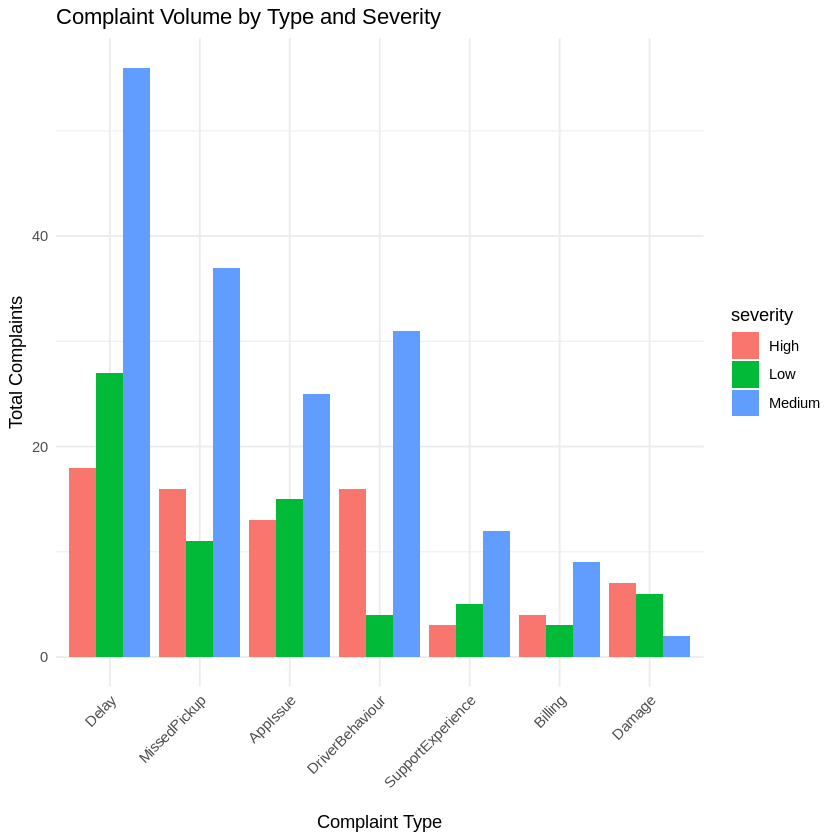

In [17]:
#Complaint Trend Analysis
complaint_trend <- complaints %>%
  group_by(complaint_type, severity) %>%
  summarise(
    total          = n(),
    avg_resolution = round(mean(resolution_days, na.rm=TRUE), 2),
    avg_compensation = round(mean(compensation_amount, na.rm=TRUE), 2),
    .groups="drop"
  ) %>%
  arrange(desc(total))

print(complaint_trend)

ggplot(complaint_trend, aes(x=reorder(complaint_type, -total),
                             y=total, fill=severity)) +
  geom_bar(stat="identity", position="dodge") +
  labs(title="Complaint Volume by Type and Severity",
       x="Complaint Type", y="Total Complaints") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1))

# A tibble: 24 × 7
   event_type    device_type total_events failed_events failure_rate avg_latency
   <chr>         <chr>              <int>         <int>        <dbl>       <dbl>
 1 chat_escalat… Android               16            10         62.5        533.
 2 chat_escalat… Web                    8             5         62.5        526.
 3 payment_retry Android               34            11         32.4        461.
 4 chat_escalat… iOS                   14             4         28.6        388.
 5 payment_retry iOS                   25             7         28          464.
 6 payment_retry Web                   10             1         10          534.
 7 cancel_attem… Android               14             0          0          439.
 8 cancel_attem… Web                    5             0          0          353.
 9 cancel_attem… iOS                    9             0          0          419.
10 chat_opened   Android               47             0          0          445.
# ℹ 14 mo

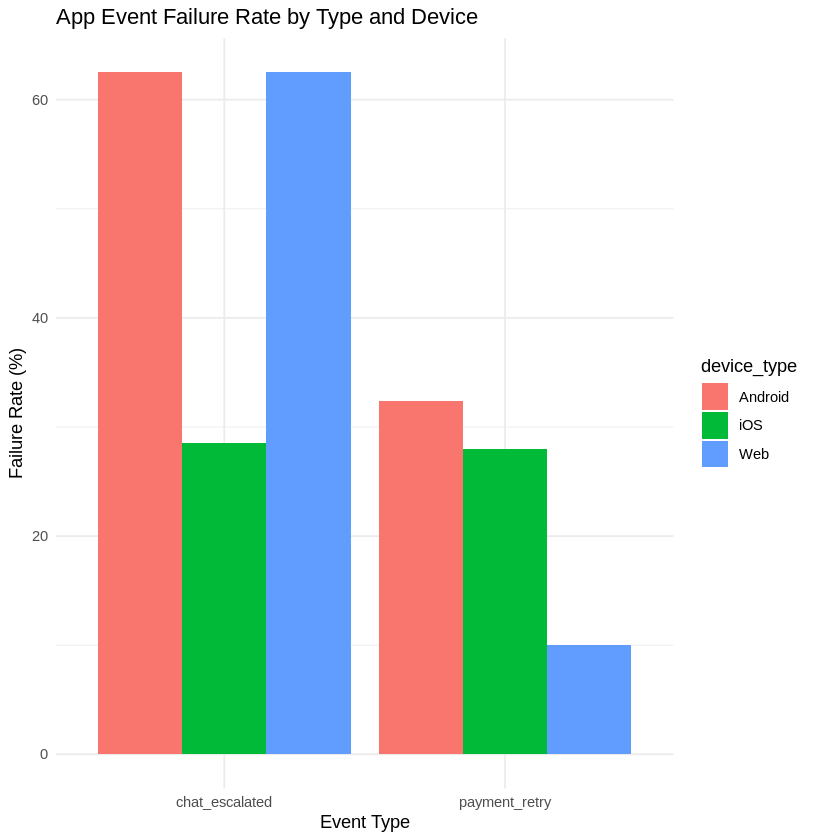

In [18]:
#App Performance Analysis
app_performance <- app_events %>%
  group_by(event_type, device_type) %>%
  summarise(
    total_events   = n(),
    failed_events  = sum(success_flag==0),
    failure_rate   = round(sum(success_flag==0)/n()*100, 2),
    avg_latency    = round(mean(api_latency_ms), 2),
    max_latency    = round(max(api_latency_ms), 2),
    .groups="drop"
  ) %>%
  arrange(desc(failure_rate))

print(app_performance)

ggplot(app_performance %>% filter(failed_events > 0),
       aes(x=event_type, y=failure_rate, fill=device_type)) +
  geom_bar(stat="identity", position="dodge") +
  labs(title="App Event Failure Rate by Type and Device",
       x="Event Type", y="Failure Rate (%)") +
  theme_minimal()

               Metric  Value
1    Total Deliveries 950.00
2        On Time Rate  64.84
3        Delayed Rate  21.26
4         Failed Rate  13.89
5 Avg Customer Rating   3.86
6   Avg Delivery Cost  12.84
7    Total Complaints 320.00
8   Avg Loyalty Score  59.69


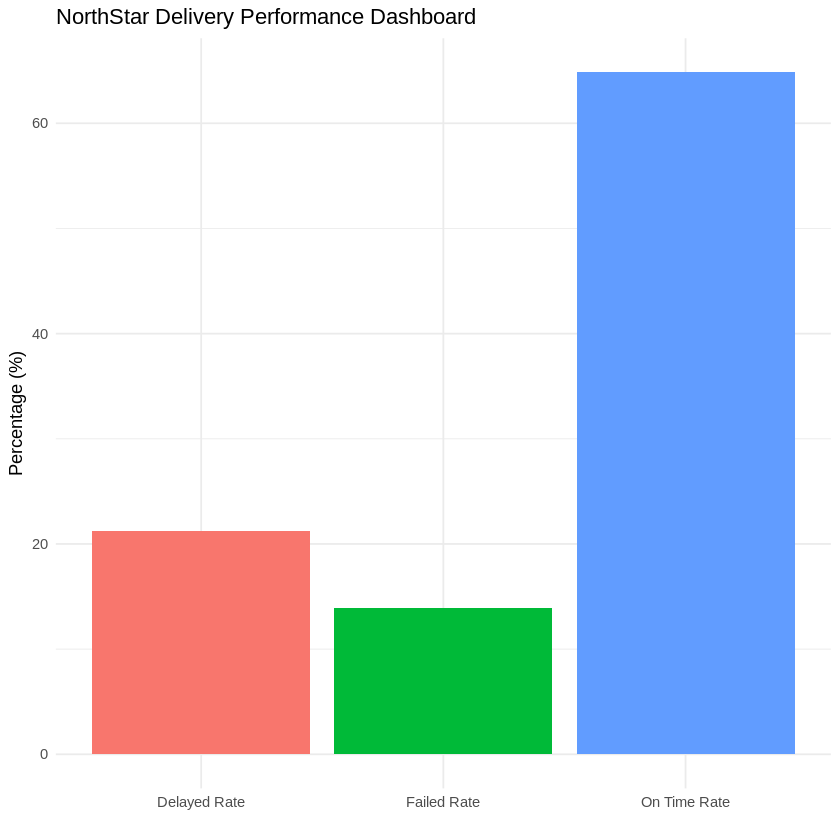

In [19]:
#Combined Performance Dashboard
dashboard <- data.frame(
  Metric = c(
    "Total Deliveries",
    "On Time Rate",
    "Delayed Rate",
    "Failed Rate",
    "Avg Customer Rating",
    "Avg Delivery Cost",
    "Total Complaints",
    "Avg Loyalty Score"
  ),
  Value = c(
    nrow(deliveries),
    round(sum(deliveries$delivery_status=="OnTime")/nrow(deliveries)*100, 2),
    round(sum(deliveries$delivery_status=="Delayed")/nrow(deliveries)*100, 2),
    round(sum(deliveries$delivery_status=="Failed")/nrow(deliveries)*100, 2),
    round(mean(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2),
    round(mean(deliveries$fuel_or_charge_cost, na.rm=TRUE), 2),
    nrow(complaints),
    round(mean(customers$loyalty_score, na.rm=TRUE), 2)
  )
)

print(dashboard)

ggplot(dashboard[2:4,], aes(x=Metric, y=Value, fill=Metric)) +
  geom_bar(stat="identity") +
  labs(title="NorthStar Delivery Performance Dashboard",
       x="", y="Percentage (%)") +
  theme_minimal() +
  theme(legend.position="none")

In [20]:
write.csv(deliveries, "deliveries.csv", row.names = FALSE)
write.csv(corr_data, "corr_data.csv", row.names = FALSE)
write.csv(hub_scores, "hub_scores.csv", row.names = FALSE)
write.csv(driver_performance, "driver_performance.csv", row.names = FALSE)
write.csv(vehicle_health, "vehicle_health.csv", row.names = FALSE)
write.csv(customer_segmentation, "customer_segmentation.csv", row.names = FALSE)
write.csv(complaint_trend, "complaint_trend.csv", row.names = FALSE)
write.csv(dashboard, "dashboard_summary.csv", row.names = FALSE)